In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")
# hoac: from sklearn.datasets
print(df.head())
print(f"Số dòng của dữ liệu: {df.shape[0]}")
print(f"Số cột của dữ liệu: {df.shape[1]}")
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Số dòng của dữ liệu: 150
Số cột của dữ liệu: 5
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [ ]:
print("Mean:")
print(df.mean(numeric_only=True))
print("Median:")
print(df.median(numeric_only=True))
print("Mode:")
print(df.mode(numeric_only=True))
print("Var:")
print(df.var(numeric_only=True))
print("Std:")
print(df.std(numeric_only=True))
print("Min:")
print(df.min(numeric_only=True))
print("Max:")
print(df.max(numeric_only=True))
print("Q1:")
print(df.quantile(0.25, numeric_only=True))
print("Q3:")
print(df.quantile(0.75, numeric_only=True))
print("IQR:")
iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
print(iqr)

Mean:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64
Median:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64
Mode:
   sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.0           1.4          0.2
1           NaN          NaN           1.5          NaN
Var:
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64
Std:
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64
Min:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64
Max:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64
Q1:
sepal_length    5.1
sepal_width     2.8
petal_length    1.6
petal_width     0.3
Name: 0.25, dtype: float64
Q3:
sepal_length    6.4
sepal_width     3.3
pet

In [ ]:
mean = df.groupby("species").mean(numeric_only=True)
print(f"Mean của dữ liệu theo species: \n{mean}")
std = df.groupby("species").std(numeric_only=True)
print("\n")
print(f"Std của dữ liệu theo species: \n{std}")

Mean của dữ liệu theo species: 
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


Std của dữ liệu theo species: 
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


Ở đây, ta có thể nhận xét nhanh là kích thước của loài virginica lớn hơn hẳn 2 loài còn lại là setosa và versicolor.

<Axes: xlabel='sepal_length', ylabel='Density'>

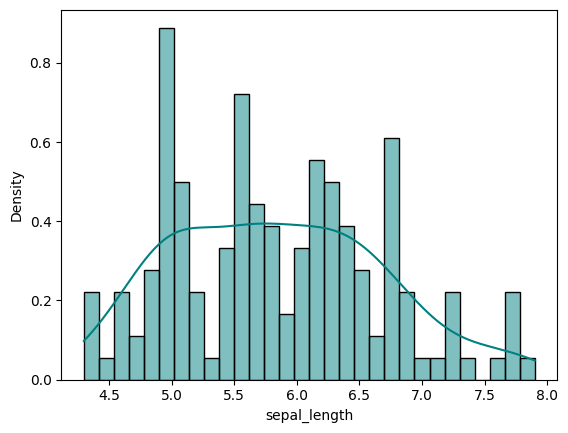

In [ ]:
sns.histplot(df['sepal_length'], bins=30, kde=True, color="teal", stat="density")

Phân phối này có khá nhiều đỉnh ở vùng giữa. Nên hình dạng uốn cong lên vừa ở giữa.

<Axes: xlabel='sepal_width', ylabel='Density'>

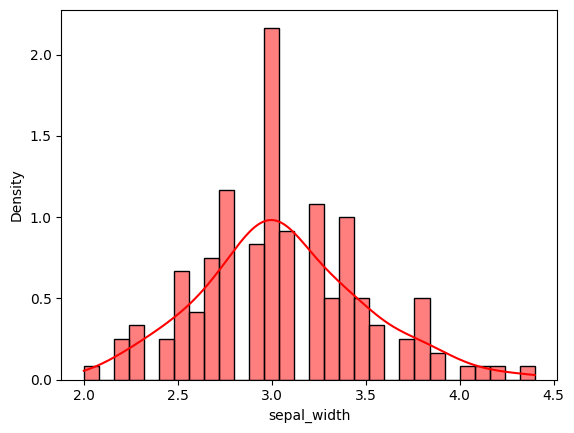

In [ ]:
sns.histplot(df['sepal_width'], bins=30, kde=True, color="red", stat="density")

Phân phối này có hình dạng khá giống phân phối chuẩn.

<Axes: xlabel='petal_length', ylabel='Density'>

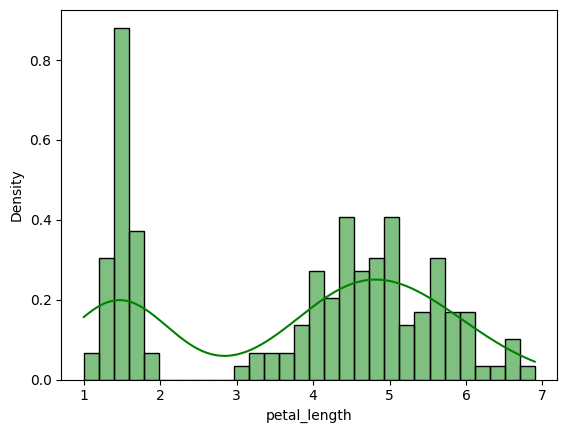

In [ ]:
sns.histplot(df['petal_length'], bins=30, kde=True, color="green", stat="density")

Ở phân phối này, ta có thể thấy 2 đỉnh cao rõ rệt cách nhau, ở giữa 2 đỉnh này, độ cao thấp hơn hẳn nên vùng này trũng xuống.

<Axes: xlabel='petal_width', ylabel='Density'>

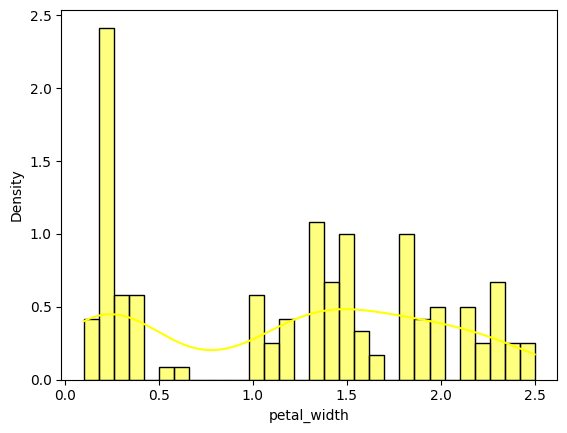

In [ ]:
sns.histplot(df['petal_width'], bins=30, kde=True, color="yellow", stat="density")

Khá tương tự với hình dạng phân phối của biến petal_length.

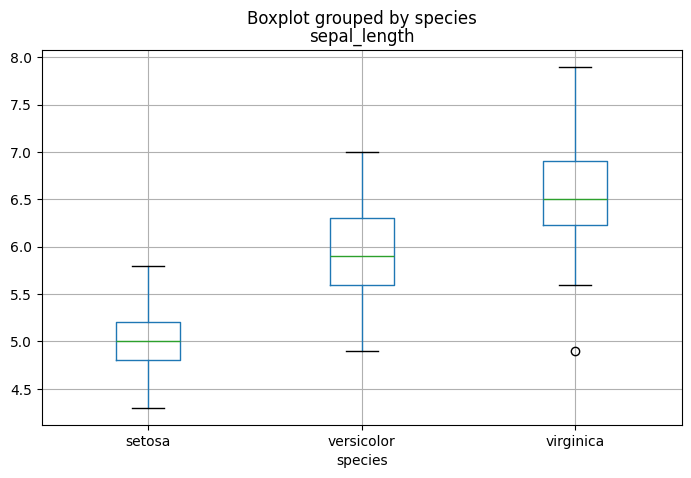

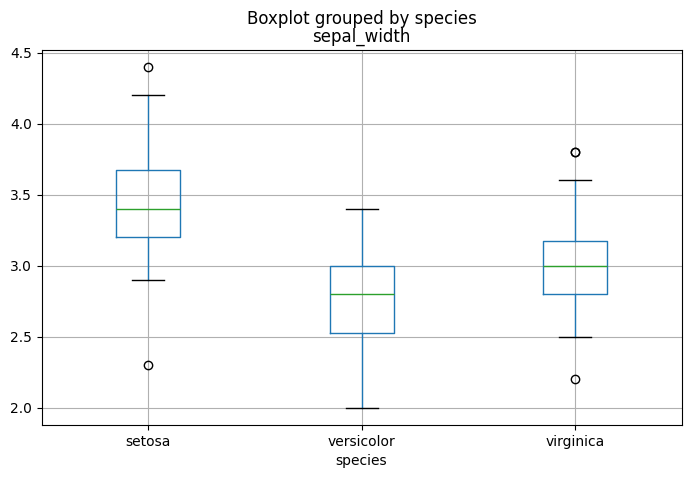

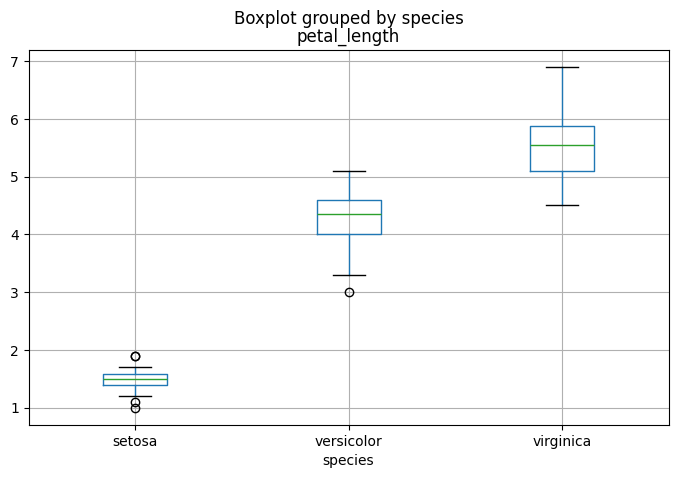

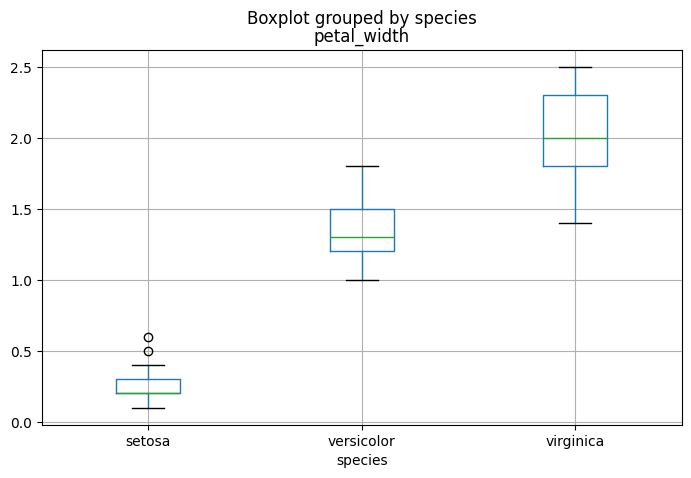

In [ ]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='species', figsize=(8, 5))

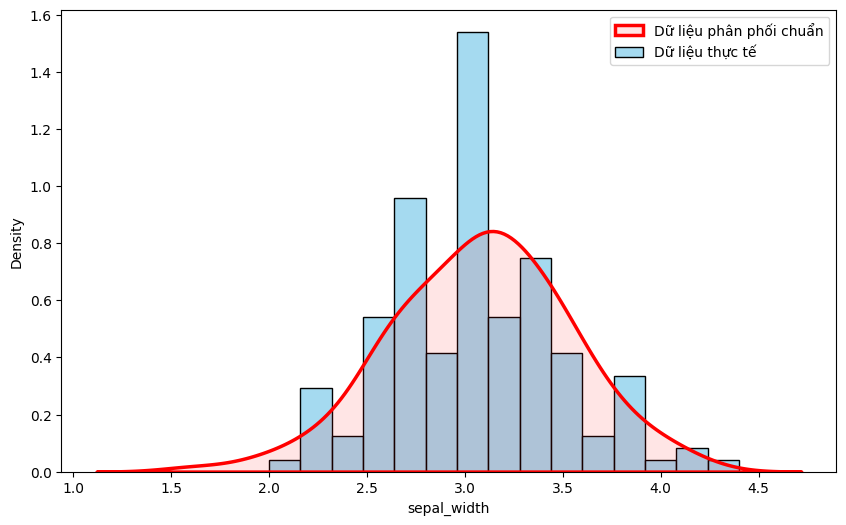

In [ ]:
fake_distribution = np.random.normal(loc = df['sepal_width'].mean(numeric_only=True), scale = df['sepal_width'].std(numeric_only=True), size = len(df['sepal_width']))
plt.figure(figsize=(10, 6))
sns.histplot(df['sepal_width'], kde=False, stat="density", color="skyblue", label="Dữ liệu thực tế", bins=15)
sns.kdeplot(data=fake_distribution, color="red", label="Dữ liệu phân phối chuẩn", linewidth=2.5, fill=True, alpha=0.1)
plt.legend()
plt.show()

Nhận xét nhanh, ta thấy đường PDF của phân phối chuẩn và histogram của sepal_width khoảng 60-70%.

In [61]:
cov_matrix = np.cov(df['petal_length'], df['petal_width'])
print(cov_matrix)
print(f"Mức độ tương quan giữa petal_length và petal_width: {np.round(cov_matrix[0, 1], 2)}\n")

cor_matrix = np.corrcoef(df['petal_length'], df['petal_width'])
print(cor_matrix)
print(f"Hiệp phương sai giữa petal_length và petal_width: {np.round(cor_matrix[0, 1], 2)}\n")

[[3.11627785 1.2956094 ]
 [1.2956094  0.58100626]]
Mức độ tương quan giữa petal_length và petal_width: 1.3

[[1.         0.96286543]
 [0.96286543 1.        ]]
Hiệp phương sai giữa petal_length và petal_width: 0.96



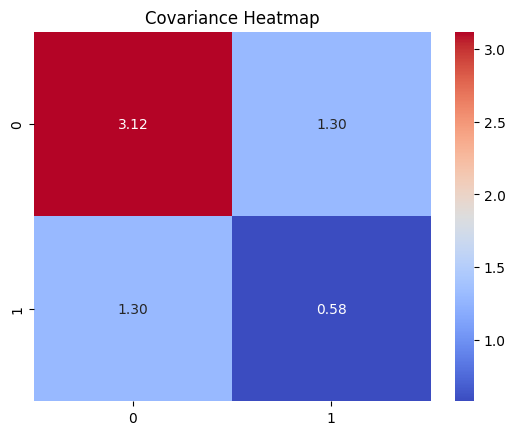

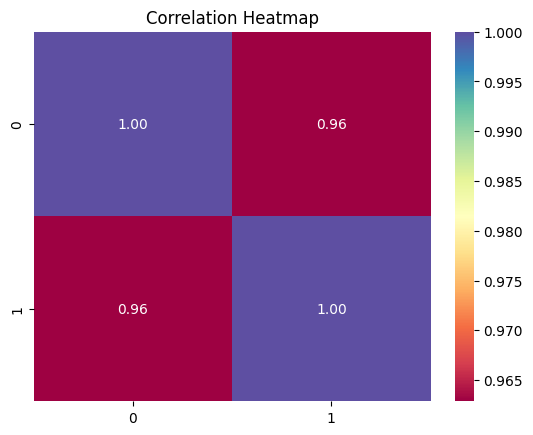

In [60]:
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Covariance Heatmap")
plt.figure()
sns.heatmap(cor_matrix, annot=True, cmap="Spectral", fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

Có dấu hiệu đa cộng tuyến giữa petal_length và petal_width (cũng khá hiển nhiên vì chỉ số này thuộc về chung của petal).
-> kiểm chứng một insight.

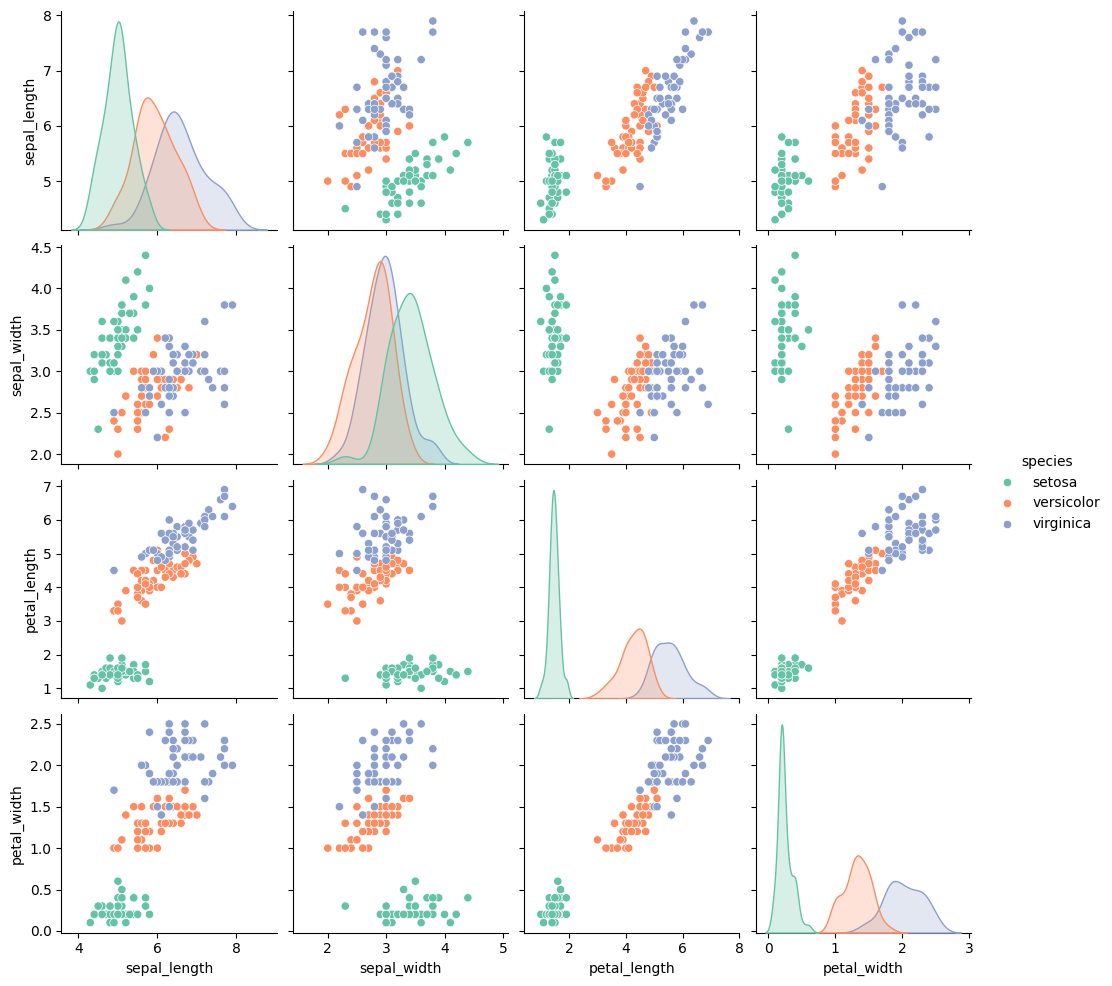

In [62]:
sns.pairplot(df, hue='species', palette='Set2')
plt.show()

Ta có thể thấy các cá thể setosa nằm khá xa so với 2 loài còn lại trên biểu đồ.

Xác suất hậu nghiệm P(B|+): 0.1667
0.8319327731092436


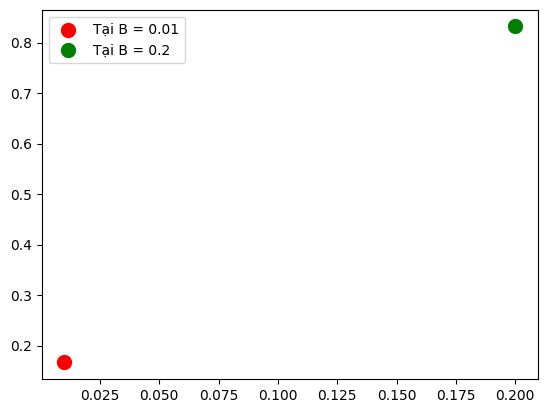

In [75]:
B = 0.01
Pos_B = 0.99
Pos_nB = 0.05
Pos = Pos_B * B + Pos_nB*(1- B)
B_Pos = Pos_B * B / Pos
print(f"Xác suất hậu nghiệm P(B|+): {np.round(B_Pos, 4)}")
# Điểm 1: B = 0.01
pos_01 = (Pos_B * 0.01) / (Pos_B * 0.01 + Pos_nB * (1 - 0.01))
plt.scatter(0.01, pos_01, color='red', s=100, zorder=5, label='Tại B = 0.01')
# Điểm 2: B = 0.2
pos_02 = (Pos_B * 0.2) / (Pos_B * 0.2 + Pos_nB * (1 - 0.2))
plt.scatter(0.2, pos_02, color='green', s=100, zorder=5, label='Tại B = 0.2')
plt.legend()
plt.show()

Ta có thể hiểu đơn giản rằng, giả sử xét 10000 người, tỉ lệ mắc bệnh là 0.01. Như vậy, sẽ có 100 người mắc bệnh và 9900 người khỏe mạnh.

Nhóm bị bệnh thực sự ($1\%$): Có 100 người.
Xét nghiệm chính xác 99%, tìm ra được: 99 người dương tính thật.

Nhóm bị bệnh thực sự ($99\%$): Có 9900 người.
Xét nghiệm chính xác 99%, tìm ra được: 495 người dương tính thật.

-> Ta nhận ra rằng, dù tỉ lệ xét nghiệm cao, nhưng xét trên số người ít. Thì trường hợp đó vẫn thấp hơn so với tổng thể. Từ đó, dẫn đến hiệu ứng "phản trực giác".

In [80]:
data = {
    'text': [
        'nhận quà miễn phí ngay hôm nay',          # Spam
        'trúng thưởng quà tặng miễn phí cực lớn',    # Spam
        'miễn phí dùng thử phần mềm nhận quà',     # Spam
        'bấm vào đây để nhận quà độc quyền',       # Spam
        'ngày mai chúng ta có lịch họp phòng',      # Ham
        'gửi tôi tài liệu chuẩn bị cho cuộc họp',    # Ham
        'cuộc họp diễn ra vào lúc chín giờ sáng',   # Ham
        'nhắc lịch họp hội đồng quản trị',          # Ham
        'bạn có rảnh để đi họp không',             # Ham
        'vui lòng mang theo tài liệu họp quà lưu niệm' # Ham (email thường có từ quà)
    ],
    'label': [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

spam_df = df[df['label'] == 1]
ham_df = df[df['label'] == 0]
p_spam = len(spam_df) / len(df)
p_ham = len(ham_df) / len(df)

keywords = ['quà', 'miễn', 'họp']

def count_word_in_df(word, target_df):
    return target_df['text'].str.contains(word).sum()

likelihoods = {}
for word in keywords:
    likelihoods[word] = {
        1: (count_word_in_df(word, spam_df) + 1) / (len(spam_df) + 2), # Nhóm Spam
        0: (count_word_in_df(word, ham_df) + 1) / (len(ham_df) + 2)    # Nhóm Ham
    }

def predict_spam_probability(email_text):
    posterior_spam = p_spam
    posterior_ham = p_ham

    # Kiểm tra từng từ khóa xem có xuất hiện trong email mới không
    for word in keywords:
        if word in email_text:
            # Nếu CÓ từ khóa: nhân với xác suất từ đó xuất hiện trong nhóm
            posterior_spam *= likelihoods[word][1]
            posterior_ham *= likelihoods[word][0]
        else:
            # Nếu KHÔNG CÓ từ khóa: nhân với xác suất từ đó KHÔNG xuất hiện trong nhóm
            posterior_spam *= (1 - likelihoods[word][1])
            posterior_ham *= (1 - likelihoods[word][0])

    # Chuẩn hóa
    total = posterior_spam + posterior_ham
    p_spam_given_email = posterior_spam / total
    p_ham_given_email = posterior_ham / total

    return p_ham_given_email, p_spam_given_email

p_h, p_s = predict_spam_probability('bạn nhận được một món quà')
label = "SPAM ❌" if p_s > p_h else "HAM (AN TOÀN)  "
print(f"Email 'bạn nhận được một món quà', được đánh giá là {label}")

p_h, p_s = predict_spam_probability('lịch họp ngày mai bị hoãn')
label = "SPAM ❌" if p_s > p_h else "HAM (AN TOÀN)  "
print(f"Email 'lịch họp ngày mai bị hoãn', được đánh giá là {label}")

Email 'bạn nhận được một món quà', được đánh giá là SPAM ❌
Email 'lịch họp ngày mai bị hoãn', được đánh giá là HAM (AN TOÀN)  
